# Active Brownian Particle Systems

## Overview

### Questions

* How can we model particles with self-induced **active forces**?

### Objectives

* Write an **MD simulation** for spherical **active** particles using the **Active Brownian Particle (ABP) model** 
* Learn how to implement a simulation with the **OverdampedViscous** method and **rotational diffusion** to intialize and thermalize an active particle system that we can then visualize.


## Boilerplate Code

In [1]:
import itertools
import gsd.hoomd
import hoomd
import numpy

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "active.gsd")
![ -e "$fn" ] && rm "$fn"

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(snapshot.particles.position), radius=0.5
    )
    geometry.material = fresnel.material.Material(
        color=[0, 0, 0], roughness=0.5, primitive_color_mix=1.0
    )
    geometry.position[:] = snapshot.particles.position[:]   
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.outline_width = 0.04

    # Draw velocity arrows
    v = snapshot.particles.velocity[:]
    pos = snapshot.particles.position[:]

    speed = numpy.linalg.norm(v, axis=1)
    mask = speed > 1e-8

    if numpy.any(mask):
        pos = pos[mask]
        v = v[mask]

        scale = 4
        v_scaled = v * scale

        start = pos
        end = pos + v_scaled
        mid = start + 0.85 * (end - start)

        
        vec = fresnel.geometry.Cylinder(
            scene, N=len(start), radius=0.05
        )
        vec.material = fresnel.material.Material(
            color=(0.15, 0.25, 0.85), roughness=0.25
        )
        vec.points[:] = numpy.stack([start, mid], axis=1)

        # spheres in place of arrow heads
        heads = fresnel.geometry.Sphere(
            scene, N=len(start), radius=0.10
        )
        heads.material = fresnel.material.Material(
            color=(0.15, 0.25, 0.85), roughness=0.15
        )
        heads.position[:] = end
        
    # scene lights
    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=numpy.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=numpy.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(0, 0, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

## Simulating Brownian Active Particles

In this part of the tutorial, we will create a simulation of **self-propelled** active particles using the **Active Brownian Particle (ABP) model**. 

### Péclet number and activity

A key quantity that you may want to control in your simulations is the **Péclet number (Pe)**. This is a key dimensionless parameter in active matter that quantifies the relative strength of persistent active motion versus random thermal diffusion. It’s critical for determining whether MIPS occurs. For spherical ABPs in 2D this is typically defined as $ Pe = v_{0} * \sigma / D_{r}$ where 
- $v_{0}$ = self-propulsion speed (active force per friction)
- sigma = particle diameter (typically = 1 in reduced units)
- and $D_{r}$ = rotational diffusion coefficient

In HOOMD-blue, the propulsion velocity is controlled by applying an active force to particles in the system. The relationship between these quantities is $v_{0} = F_{active} / \gamma$ where $\gamma$ is the translational drag coefficient (often = 1 in overdamped Brownian dynamics). $D_{r}$ is typically set directly in the integrator as rotational diffusion. Thus we can define Pe: 
$$ Pe = \frac{F_{active} * \sigma}{D_{r} * \gamma}$$

Activity (typically quantified by self-propulsion speed or Pélet number) drives persistent motion that breaks equilibrium detailed balance. Higher activity can induce clustering even at densities too low for passive phase separation, triggering motility-induced phase separation. Adding temperature to the simulation alters the effective persistence length of the active particles, which directly influence how long it takes for MIPS to be realized due to increasing (or decreasing) random fluctuations. Using the the OverdampedViscous method in HOOMD-blue, we essentially set the effective temperture of the system to zero. Read more about this integrator in the [HOOMD-blue documentation](https://hoomd-blue.readthedocs.io/en/latest/hoomd/md/methods/overdampedviscous.html). 

A general rule of thumb is: 
- Pe < 10: mostly homogeneous, little clustering
- Pe ≈ 20–80: MIPS starts to emerge (depending on density)
- Pe > 100: strong phase separation likely

More information on Pe numbers for different systems can be found in [Cates & Tailleur (2015)](https://doi.org/10.1146/annurev-conmatphys-031214-014710) and [Marchetti et al. (2023)](https://pubs.rsc.org/en/content/articlelanding/2023/sm/d3sm01059g). 

#### Active Brownian Particles 
Active Brownian Particles (ABPs) are among the most widely studied minimal models of active matter. They describe self-propelled particles moving in a noisy environment, where inertia is negligible and fluctuations play an essential role. In this model, particle motion is governed by **Brownian dynamics**, which incorporates stochastic forces caused by the surrounding medium. 

For example, consider the Janus particle described earlier. The self-propulsion vector points along the axis of asymmetry, while collisions with solvent molecules lead to gradual random reorientation. In HOOMD-blue, we can model ABPs by adding a persistent self-propulsion force of fixed magnitude directed along the orientation vector, and adding a **rotational diffusion** process that introduces noise to the orientation of the propulsion direction; this introduces randomness into the particle's long-time trajectory such that it decorrelates over time. Thermal noise enters the model through an integrator (typical choices includ HOOMD-blue's [OverdampedViscous](https://hoomd-blue.readthedocs.io/en/latest/hoomd/md/methods/overdampedviscous.html) or [Brownian](https://hoomd-blue.readthedocs.io/en/latest/hoomd/md/methods/brownian.html) methods), and controls the strength of both rotational and translational fluctuations. Changes in the effective temperature can alter the amount of stochastic movement experienced by the particles. 

Typical applications of ABP models include studying **motility-induced phase separation (MIPS)**, clustering behavior in dense suspensions, and collective motion in active colloidal systems which will be discussing [the following section of this tutorial series](03-Motility-Induced-Phase-Separation-In-2D.ipynb).

We can set up the initial state of the simulation in a very similar manner to previous methods we have used in [earlier hoomd MD simulation tutorials](../01-Introducing-Molecular-Dynamics/00-index.ipynb). 

## Set up the Simulation

We will first initialize a system of spherical particles with a given particle density in an array. We save an initial snapshot of the current state of the system.

In [6]:
rho = 0.3  # particle area density
simseed = 1

m = 10
N_particles = m**2
K = numpy.ceil(N_particles ** (1 / 2))
L = (N_particles / rho) ** (1 / 2)
spacing = L / K
x = numpy.linspace(-L / 2, L / 2, int(K), endpoint=False)

position_2D = numpy.array(list(itertools.product(x, repeat=2))) + [
    spacing / 2,
    spacing / 2,
]
position_3D = numpy.hstack([position_2D, numpy.zeros((N_particles, 1))])

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position_3D
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, 0, 0, 0, 0]
frame.particles.types = ["A"]
frame.particles.mass = [1] * N_particles

# randomized orientations
theta = numpy.random.uniform(0, 2*numpy.pi, N_particles)
frame.particles.orientation = numpy.column_stack((
    numpy.cos(theta / 2),        # w
    numpy.zeros(N_particles),    # x
    numpy.zeros(N_particles),    # y
    numpy.sin(theta / 2)         # z
))

with gsd.hoomd.open(name="lattice.gsd", mode="w") as f:
    f.append(frame)

Configure this simulation to run on CPU from this snapshot as we have in previous tutorials. 
We confirm that the box is correctly set to simulate in 2D by checking if `hoomd.Box.is2D` is `True`.

True. Lz = 0 in the simulation box.


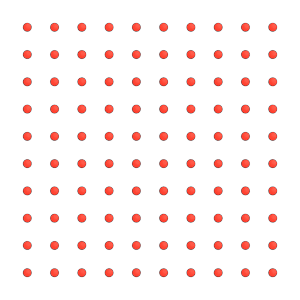

In [7]:
cpu = hoomd.device.CPU()
sim = hoomd.Simulation(device=cpu, seed=simseed)
state = sim.create_state_from_gsd(filename="lattice.gsd")

if hoomd.Box.is2D:
    print("True. Lz = 0 in the simulation box.")

render(sim.state.get_snapshot())

## Defining Interactions in an Active Particle system

This simulation uses the `OverdampedViscous` dynamics method with a drag force set by gamma. More documentation on the method `OverdampedViscous` can be found in the [HOOMD documentation](https://hoomd-blue.readthedocs.io/en/stable/hoomd/md/methods/overdampedviscous.html). Add this method our integrator.

In [9]:
kT = 0
gamma = 1

filter_all = hoomd.filter.All()
overdamped = hoomd.md.methods.OverdampedViscous(filter=filter_all)
overdamped.gamma.default = gamma

integrator = hoomd.md.Integrator(dt=0.001, integrate_rotational_dof=False)
sim.operations.integrator = integrator
integrator.methods.append(overdamped)

As [previously mentioned](01-Introduction-to-Active-Particles.ipynb), a **Péclet number (Pe)** is a commonly used dimmensionless measure that quantifies advective and diffusive transport in a system. As such, the Péclet number is a desirable parameter to control in active particle simulations. 

Below, we set our Péclet number to 3, which will put us in the regime where we can expect MIPS above certain intermediate densities. Since, we have previously set `gamma=1` and `sigma=1`, we do this by setting our `active_force = 0.3` ($F_{\text{active}}$)  and `rotational_diffusion = 0.1` ($D_{r}$), so our Péclet number is 3 according to the relation we gave in [section 01 of this tutorial sequence](01-Introduction-to-Active-Particles.ipynb): $$ Pe = \frac{F_{active} * \text{sigma}}{D_{r} * \text{gamma}}$$

Below, `hoomd.md.force.Active` is the HOOMD class used to create an active force object. `active.active_force["A"]` specifies the components of the active force for particles of type "A" in the particle's body frame. The Active force class also requires an active torque to be specified through `active.active_torque`. Here, we set this torque to zero. The active force object is then added to the integrator so that it is included in the force calculation at every timestep.

Next, we create a `rotational_diffusion_updater`, which applies rotational Brownian diffusion to each particle's orientation at every timestep. As a result, each particle gradually loses memory of its initial orientation, causing the propulsion direction to evolve over time. Without this updater, particle orientations would remain fixed, so each particle would continue swimming indefinitely in a straight line. This would correspond to **active ballistic motion**, whereas including rotational diffusion produces the **active Brownian particle (ABP)** dynamics that we aim to model here.

In [10]:
activity = 0.3
rotational_diffusion = 0.1

active = hoomd.md.force.Active(filter=filter_all)
active.active_force["A"] = (activity, 0, 0)
active.active_torque["A"] = (0, 0, 0)

integrator.forces.append(active)

rotational_diffusion_updater = active.create_diffusion_updater(
    trigger=1, rotational_diffusion=0.1
)
sim.operations += rotational_diffusion_updater

Run the simulation and get an initial snapshot.

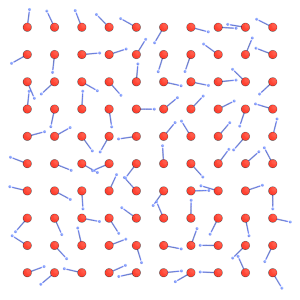

In [11]:
logger = hoomd.logging.Logger(["particle", "constraint"])
gsd_oper = hoomd.write.GSD(
    trigger=hoomd.trigger.Periodic(100),
    filename="active.gsd",
    logger=logger,
    mode="wb",
    dynamic=["momentum", "property"],
    filter=hoomd.filter.All(),
)

sim.operations += gsd_oper

sim.state.thermalize_particle_momenta(filter=filter_all, kT=kT)
sim.run(1)
render(sim.state.get_snapshot())

Thermalize the system.

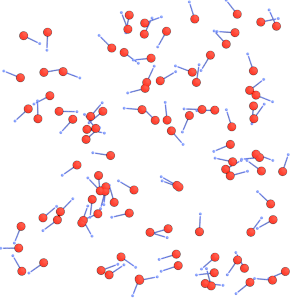

In [12]:
sim.run(10000)
render(sim.state.get_snapshot())

In this tutorial, we have successfully placed active self-propelled particles in a non-equilibrium MD simulation. However, in this system, it is difficult to determine by visual inspection alone that the particles are driven by an active propulsion force. In contrast, some other active systems display collective effects of propulsion that are more readily apparent in a single frame. 

In the [next tutorial](03-Motility-Induced-Phase-Separation-In-2D.ipynb), we will explore one such system: a 2D system of purely repulsive active particles that exhibit gas-liquid coexistance at intermediate densities. This phenomenon is known as **motility induced phase separation (MIPS)**.